# **Data Understanding**

Menampilkan 5 data pertama:


,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9



Menampilkan deskripsi data:


,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


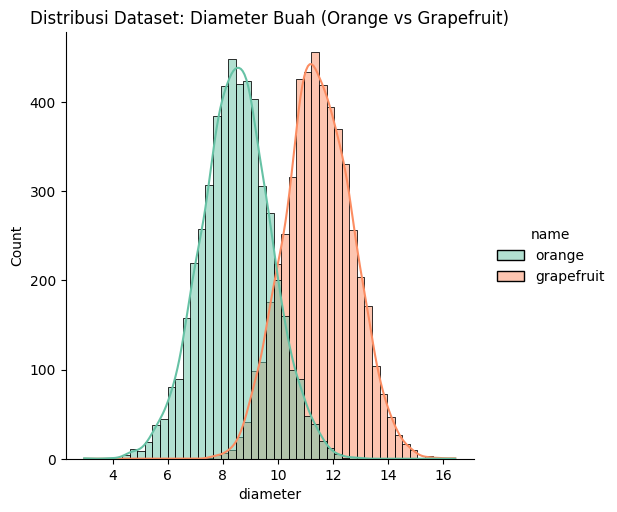

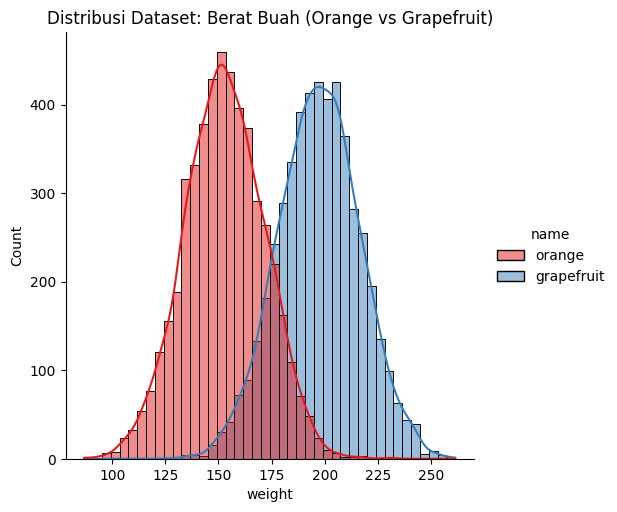

In [4]:
# %%
# ==========================================================
# TAHAP 1: PENGUMPULAN & PEMAHAMAN DATA (Data Understanding)
# ==========================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Membaca dataset
df_net = pd.read_csv('citrus.csv')
print("Menampilkan 5 data pertama:")
display(df_net.head())

# 2. Menampilkan deskripsi statistik (Mean, Min, Max, dll)
print("\nMenampilkan deskripsi data:")
display(df_net.describe())

# 3. Visualisasi distribusi data untuk memahami bentuk data
sns.displot(data=df_net, x='diameter', hue='name', kde=True, palette='Set2')
plt.title('Distribusi Dataset: Diameter Buah (Orange vs Grapefruit)')
plt.show()

sns.displot(data=df_net, x='weight', hue='name', kde=True, palette='Set1')
plt.title('Distribusi Dataset: Berat Buah (Orange vs Grapefruit)')
plt.show()

# Pra-pemrosesan Data (Data Preprocessing)

memproses data kotor menjadi siap dilatih. Meliputi Label Encoding (mengubah teks kelas jadi angka biner), memisahkan fitur dan target, serta melakukan Feature Scaling.

In [5]:
# %%
# ==========================================================
# TAHAP 2: PRA-PEMROSESAN DATA (Data Preprocessing)
# ==========================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Label Encoding: Mengubah teks kelas ('orange', 'grapefruit') menjadi angka (0 dan 1)
le = LabelEncoder()
df_net['name'] = le.fit_transform(df_net['name'])

# 2. Memisahkan Fitur Prediktor (X) dan Label/Target (y)
X = df_net.drop('name', axis=1)
y = df_net['name']

# 3. Feature Scaling: Standarisasi fitur agar rentang nilainya sama (sangat penting untuk SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Proses Data Preprocessing selesai.")

Proses Data Preprocessing selesai.


# Pembagian Data (Data Splitting)
membagi data menjadi set pelatihan dan set pengujian.

In [6]:
# %%
# ==========================================================
# TAHAP 3: PEMBAGIAN DATA (Data Splitting)
# ==========================================================
from sklearn.model_selection import train_test_split

# Membagi data dengan proporsi: 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data berhasil dibagi.")
print(f"Jumlah Data Latih (Training) : {X_train.shape[0]} sampel")
print(f"Jumlah Data Uji (Testing)    : {X_test.shape[0]} sampel")

Data berhasil dibagi.
Jumlah Data Latih (Training) : 8000 sampel
Jumlah Data Uji (Testing)    : 2000 sampel


# Pelatihan Model (Model Training)
Menginisialisasi 3 algoritma Machine Learning yang diminta dan langsung melatihnya (fit) menggunakan Training Data.

In [7]:
# %%
# ==========================================================
# TAHAP 4: PELATIHAN MODEL (Model Training)
# ==========================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# 1. Inisialisasi ketiga model
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(kernel='linear', random_state=42)
}

# 2. Melatih (training) model menggunakan data latih
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Model [{name}] berhasil dilatih.")

Model [Decision Tree] berhasil dilatih.
Model [Naive Bayes] berhasil dilatih.
Model [Support Vector Machine] berhasil dilatih.


# Evaluasi Model (Model Evaluation)

Testing Data, menghitung tingkat accuracy, mencetak laporan presisi/recall (Classification Report), menggambar Confusion Matrix, dan membandingkan hasilnya dalam bentuk grafik Bar Chart.


Model: Decision Tree
Akurasi Training : 100.00%
Akurasi Testing  : 94.15%

Classification Report (Data Uji):
              precision    recall  f1-score   support

      orange       0.94      0.95      0.94       988
  grapefruit       0.95      0.94      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



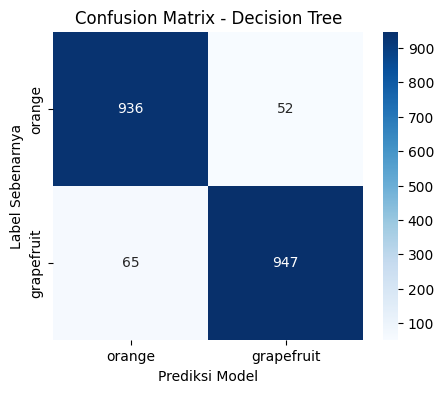


Model: Naive Bayes
Akurasi Training : 92.15%
Akurasi Testing  : 92.00%

Classification Report (Data Uji):
              precision    recall  f1-score   support

      orange       0.91      0.93      0.92       988
  grapefruit       0.93      0.91      0.92      1012

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



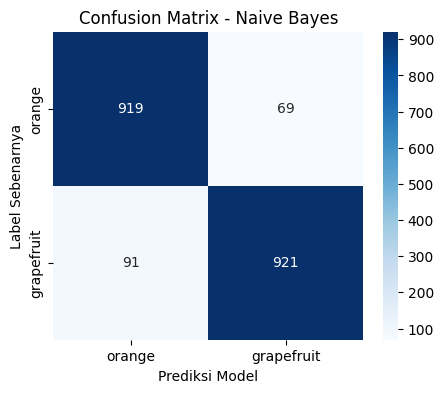


Model: Support Vector Machine
Akurasi Training : 95.78%
Akurasi Testing  : 95.15%

Classification Report (Data Uji):
              precision    recall  f1-score   support

      orange       0.93      0.98      0.95       988
  grapefruit       0.98      0.93      0.95      1012

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



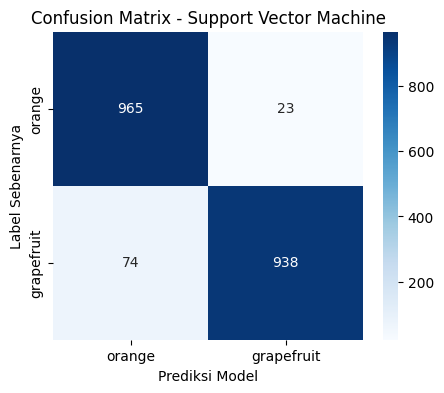

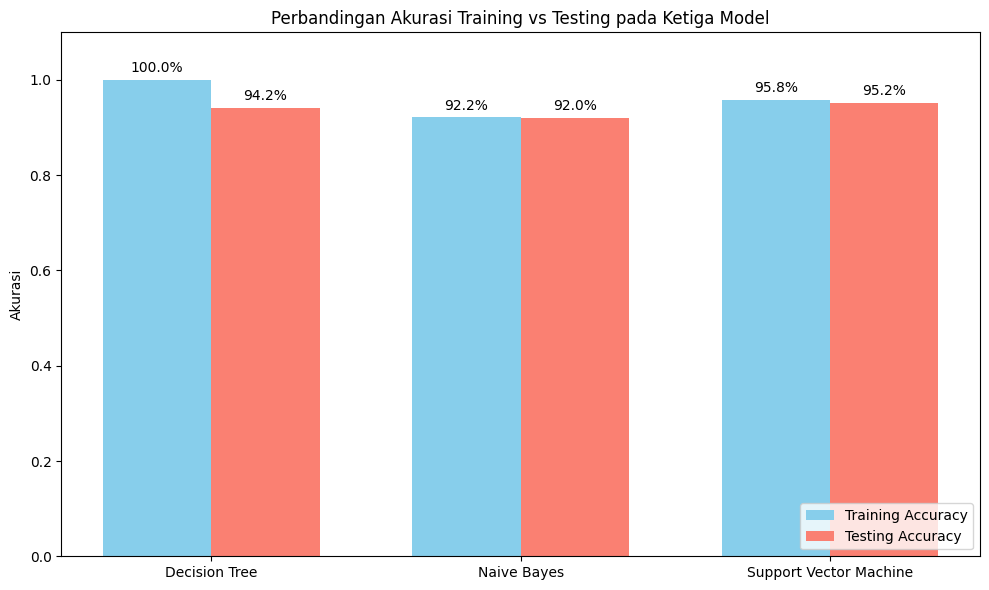

In [8]:
# %%
# ==========================================================
# TAHAP 5: EVALUASI MODEL (Model Evaluation)
# ==========================================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

train_accuracies = []
test_accuracies = []
model_names = []

for name, model in models.items():
    # Proses Prediksi
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Hitung Akurasi
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Menyimpan data akurasi untuk membuat grafik di akhir
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    model_names.append(name)

    # Tampilkan Hasil Evaluasi Teks
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Akurasi Training : {train_acc * 100:.2f}%")
    print(f"Akurasi Testing  : {test_acc * 100:.2f}%")
    print("\nClassification Report (Data Uji):")
    print(classification_report(y_test, y_test_pred, target_names=['orange', 'grapefruit']))

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['orange', 'grapefruit'],
                yticklabels=['orange', 'grapefruit'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi Model')
    plt.ylabel('Label Sebenarnya')
    plt.show()

# ==========================================================
# GRAFIK PERBANDINGAN TRAINING VS TESTING KETIGA MODEL
# ==========================================================
x_axis = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bar_train = ax.bar(x_axis - width/2, train_accuracies, width, label='Training Accuracy', color='skyblue')
bar_test = ax.bar(x_axis + width/2, test_accuracies, width, label='Testing Accuracy', color='salmon')

ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Akurasi Training vs Testing pada Ketiga Model')
ax.set_xticks(x_axis)
ax.set_xticklabels(model_names)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)

# Menambahkan persentase di atas setiap batang diagram
for bar in bar_train:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.1f}%', ha='center', va='bottom', fontsize=10)

for bar in bar_test:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()